 Các lớp trong dataset:
['healthy', 'unhealthy']


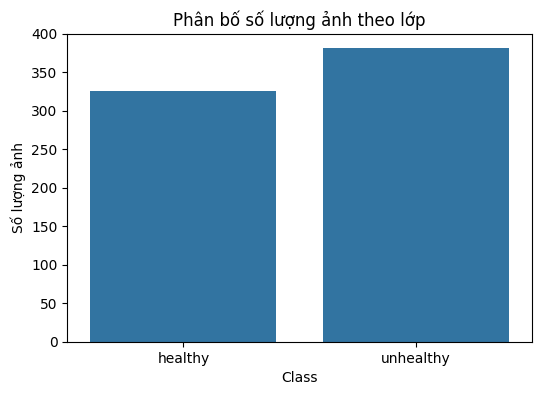

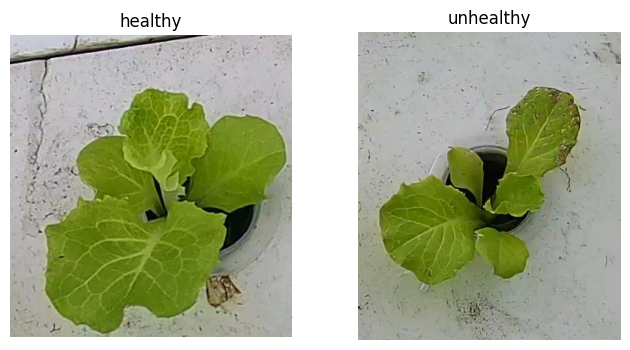

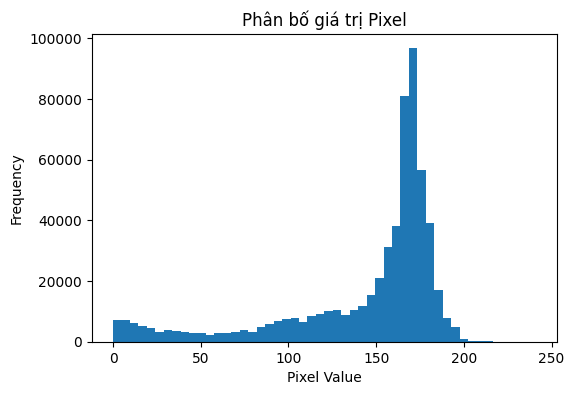

,Class,Number of Images,Percentage (%)
0,healthy,326,46.110325
1,unhealthy,381,53.889675


In [6]:
# PHẦN A: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)
# Exploratory Data Analysis

# Bước 1: Liệt kê các lớp (classes) trong dataset
print("Các lớp trong dataset:")

# Lọc ra các thư mục (loại bỏ file nếu có) trong DATA_DIR
# Mỗi thư mục đại diện cho 1 class (ví dụ: healthy, unhealthy)
classes = [c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))]
print(classes)


# Bước 2: Đếm số lượng ảnh trong mỗi lớp
data_info = []  # Danh sách lưu thông tin [tên_class, số_ảnh]

for cls in classes:
    # Đường dẫn đến thư mục của class
    cls_path = os.path.join(DATA_DIR, cls)

    # Đếm số file ảnh trong thư mục
    num_images = len(os.listdir(cls_path))

    # Lưu thông tin vào danh sách
    data_info.append([cls, num_images])

# Chuyển thành DataFrame để dễ xem và xử lý
df = pd.DataFrame(data_info, columns=["Class", "Number of Images"])
df  # Hiển thị bảng thống kê


# Bước 3: Vẽ biểu đồ cột phân bố số lượng ảnh
plt.figure(figsize=(6,4))

# Vẽ barplot: trục x là class, trục y là số lượng ảnh
sns.barplot(x="Class", y="Number of Images", data=df)

plt.title("Phân bố số lượng ảnh theo lớp")
plt.xlabel("Class")
plt.ylabel("Số lượng ảnh")
plt.show()

# MUC ĐÍCH: Kiểm tra dataset có cân bằng (balanced) hay không
# Nếu 1 class có quá nhiều/ít ảnh → có thể cần resampling


# Bước 4: Hiển thị ảnh mẫu từ mỗi lớp
plt.figure(figsize=(8,4))

for i, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)

    # Chọn ngẫu nhiên 1 ảnh từ class
    img_name = np.random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Đọc ảnh bằng OpenCV (mặc định BGR)
    img = cv2.imread(img_path)

    # Chuyển BGR → RGB để hiển thị đúng màu
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Tạo subplot: 1 hàng, số cột = số class
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")  # Ẩn trục tọa độ

plt.show()

# MỤC ĐÍCH: Quan sát trực quan sự khác biệt giữa các class
# Giúp hiểu đặc điểm visual của từng nhóm (màu sắc, texture...)


# Bước 5: Kiểm tra kích thước ảnh
img_shapes = []  # Danh sách lưu (height, width) của ảnh

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)

    # Lấy mẫu 20 ảnh đầu tiên từ mỗi class
    for img_name in os.listdir(cls_path)[:20]:
        img = cv2.imread(os.path.join(cls_path, img_name))

        if img is not None:  # Kiểm tra ảnh đọc thành công
            # img.shape = (height, width, channels)
            # Lấy [:2] để bỏ qua số kênh màu
            img_shapes.append(img.shape[:2])

# Hiển thị 5 kích thước ảnh đầu tiên
img_shapes[:5]

# MỤC ĐÍCH: Kiểm tra ảnh có cùng kích thước không
# Nếu khác nhau → cần resize về kích thước chuẩn (224x224)


# Bước 6: Phân bố giá trị pixel
# Đọc 1 ảnh bất kỳ để phân tích
img = cv2.imread(os.path.join(cls_path, img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))

# img.ravel() → flatten ảnh 3D thành 1D array
# bins=50 → chia histogram thành 50 khoảng
plt.hist(img.ravel(), bins=50)

plt.title("Phân bố giá trị Pixel")
plt.xlabel("Pixel Value")  # Giá trị pixel (0-255)
plt.ylabel("Frequency")     # Tần suất xuất hiện
plt.show()

# MỤC ĐÍCH: Hiểu phân bố độ sáng của ảnh
# - Nếu tập trung ở 1 vùng → ảnh tối/sáng đều
# - Nếu phân bố rộng → độ tương phản cao
# Giúp quyết định có cần điều chỉnh brightness/contrast không


# Bước 7: Tính tỷ lệ phần trăm mỗi lớp
# Tổng số ảnh trong toàn bộ dataset
total = df["Number of Images"].sum()

# Tính % = (số_ảnh_class / tổng_số_ảnh) * 100
df["Percentage (%)"] = (df["Number of Images"] / total) * 100

df  # Hiển thị bảng kết quả

# MỤC ĐÍCH: Đánh giá mức độ mất cân bằng dataset
# - Nếu 1 class chiếm >70% → highly imbalanced
# - Cần xem xét sử dụng class weights hoặc oversampling/undersampling


# KẾT LUẬN EDA:
# 1. Số lượng class và tên class
# 2. Phân bố số lượng ảnh (balanced/imbalanced?)
# 3. Hình ảnh mẫu để hiểu visual features
# 4. Kích thước ảnh khác nhau → cần resize
# 5. Phân bố pixel → quyết định augmentation strategy
# 6. Tỷ lệ % → quyết định sampling strategy